In [1]:
# ---Imports------------------------------------------------------------------

from pathlib import Path

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ---Notebook configuration---------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


# ---Project paths------------------------------------------------------------

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

DEV_DATA_PATH = PROCESSED_DATA_DIR / "dev_modeling_dataset.parquet"


# ---Sanity check-------------------------------------------------------------

print("Project root:", PROJECT_ROOT.resolve())
print("Development dataset path:", DEV_DATA_PATH.resolve())
print("File exists:", DEV_DATA_PATH.exists())

Project root: C:\Users\zeina
Development dataset path: C:\Users\zeina\data\processed\dev_modeling_dataset.parquet
File exists: True


# Load Engineered Development Dataset

In [2]:
# ---Load dataset--------------------------------------------------------------

df = pd.read_parquet(DEV_DATA_PATH)

print("Dataset loaded successfully.")
print()


# ---Basic shape check---------------------------------------------------------

print("Dataset shape:")
print(df.shape)
print()


# ---Preview columns-----------------------------------------------------------

print("First 10 columns:")
print(df.columns[:10])
print()


# ---Target distribution-------------------------------------------------------

print("Target distribution:")
print(df["isFraud"].value_counts(normalize=True))
print()


# ---Check removed identifiers-------------------------------------------------

for col in ["TransactionID", "TransactionDT"]:
    if col in df.columns:
        print(f"WARNING: {col} still present in dataset")

Dataset loaded successfully.

Dataset shape:
(472432, 464)

First 10 columns:
Index(['isFraud', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3',
       'card4', 'card5', 'card6', 'addr1'],
      dtype='object')

Target distribution:
isFraud
0   0.9649
1   0.0351
Name: proportion, dtype: float64



# Define Features and Target

In [3]:
# ---Target variable-----------------------------------------------------------
target_col = "isFraud"

y = df[target_col]

# ---Feature matrix------------------------------------------------------------
X = df.drop(columns=[target_col])

# ---Basic verification--------------------------------------------------------
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print()

print("Number of features:", X.shape[1])

Feature matrix shape: (472432, 463)
Target vector shape: (472432,)

Number of features: 463


# Time-Aware Train / Validation Split

In [4]:
# ---Create time-aware split---------------------------------------------------

n_rows = len(X)
split_index = int(n_rows * 0.8)

X_train = X.iloc[:split_index].copy()
X_valid = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_valid = y.iloc[split_index:].copy()


# ---Sanity check--------------------------------------------------------------

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

print("\nFraud rate (train):", y_train.mean())
print("Fraud rate (valid):", y_valid.mean())

Train shape: (377945, 463)
Validation shape: (94487, 463)

Fraud rate (train): 0.03411872097792007
Fraud rate (valid): 0.039201159947929345


# Identify Feature Types

In [5]:
# ---Detect feature types------------------------------------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 406
Categorical features: 35


# Build Preprocessing Pipelines

In [6]:
# ---Numeric preprocessing-----------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
# ---Categorical preprocessing-------------------------------------------------
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
# ---Column transformer--------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Logistic Regression Baseline Model

In [9]:
# ---Define model--------------------------------------------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)
#---Full modeling pipeline----------------------------------------------------
model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", log_reg)
    ]
)
# ---Model training------------------------------------------------------------
model.fit(X_train, y_train)
print("Model training complete.")

# ---Probability predictions---------------------------------------------------
y_pred_proba = model.predict_proba(X_valid)[:, 1]


# ---Default threshold predictions---------------------------------------------
y_pred = (y_pred_proba >= 0.5).astype(int)

Model training complete.


# Baseline Model Evaluation : Imbalanced: No Accuracy

ROC-AUC: 0.8656137607137557
PR-AUC: 0.4697754496942611
Precision: 0.13236631502364496
Recall: 0.7859071274298056
F1 Score: 0.22657222914072228


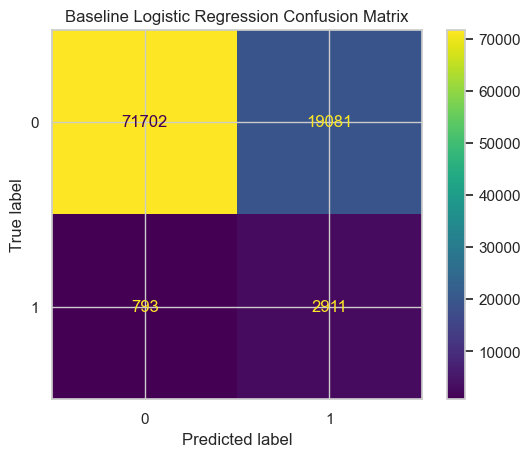

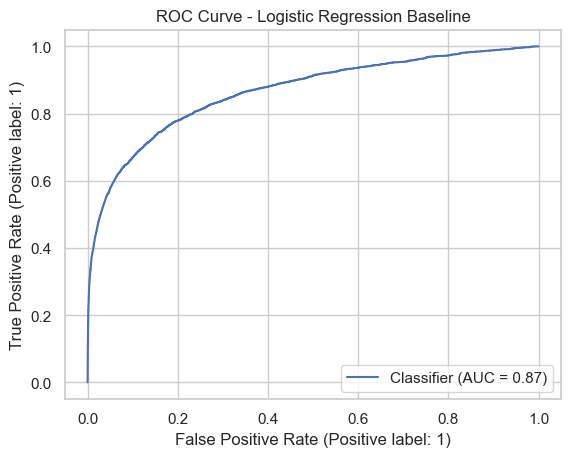

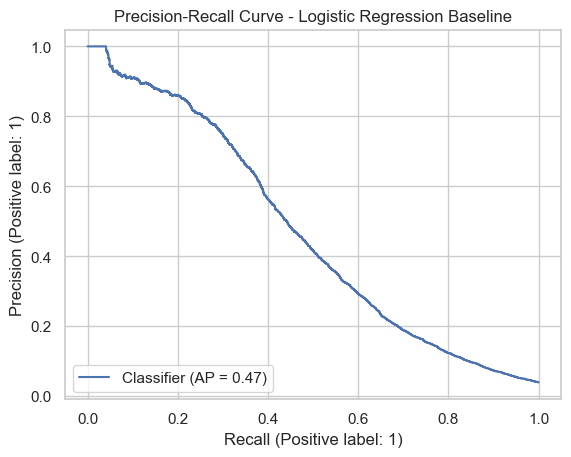

,Metric,Value
0,ROC-AUC,0.8656
1,PR-AUC,0.4698
2,Precision,0.1324
3,Recall,0.7859
4,F1,0.2266


In [12]:
# ---Core metrics--------------------------------------------------------------
roc_auc = roc_auc_score(y_valid, y_pred_proba)
pr_auc = average_precision_score(y_valid, y_pred_proba)

precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ---Confusion matrix----------------------------------------------------------
cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

# ---Roc Curve--------------------------------------------------------------------
RocCurveDisplay.from_predictions(y_valid, y_pred_proba)

plt.title("ROC Curve - Logistic Regression Baseline")
plt.show()

# ---Precision-Recall Curve----------------------------------------------------------
PrecisionRecallDisplay.from_predictions(y_valid, y_pred_proba)

plt.title("Precision-Recall Curve - Logistic Regression Baseline")
plt.show()

#--- Baseline Model Summary--------------------------------------------------------
results = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1"],
    "Value": [roc_auc, pr_auc, precision, recall, f1]
})

results

# Interpretation:

The logistic regression baseline demonstrates strong ranking performance with
ROC-AUC ≈ 0.87 and PR-AUC ≈ 0.47, indicating that the engineered features
contain meaningful signal for distinguishing fraudulent from legitimate
transactions.

Recall is high (~0.79), meaning the model identifies the majority of fraudulent
transactions. Precision is relatively low (~0.12), reflecting the severe class
imbalance in the dataset (~3.5% fraud). As a result, many transactions flagged
as fraud are false positives, which is expected when using a fixed 0.5
probability threshold in highly imbalanced classification problems.

The confusion matrix shows that the model successfully captures most fraud
cases but at the cost of a substantial number of legitimate transactions being
incorrectly flagged. This behavior is typical for early-stage fraud detection
models, where recall is prioritized to avoid missing fraudulent activity.

Overall, the baseline confirms that the feature engineering pipeline produces
predictive signal and provides a reliable reference point for evaluating more
expressive nonlinear models.